# 01 · EDA — proving the single-signer trap

**Person A · issue #2.** The Kaggle *ASL Alphabet* dataset looks like 87k independent
images, but it is really **consecutive video frames of one signer, in one room, under
one lighting setup**. This notebook is the *evidence* for that claim, so the whole team
internalises **why we never use a random train/val split** — and why the leakage-safe
frame-range split (#3) and our own webcam test set (#15) are the only honest benchmarks.

What we show, in order:
1. **Class balance** — is any class under-represented?
2. **Near-duplicate frames** — neighbouring frames are near-identical (shown *and* measured).
3. **The consequence** — why a random split reports a fake ~99.9%.
4. **Confusable groups** — M/N/S/T, A/E, K/V, the pairs to watch in the confusion analysis (#7, #16).

## 0 · Setup
Make `import src.data` work from `notebooks/`, resolve the dataset root (overridable with `$ASL_DATA_ROOT`), and ensure `docs/figures/` exists so the notebook is self-sufficient. All paths are resolved relative to the repo root, so this runs on anyone's machine.

In [1]:
import os
import sys
from pathlib import Path

# --- make `import src.data` work whether the kernel starts in notebooks/ or repo root ---
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "data.py").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "src" / "data.py").exists(), "could not locate repo root"
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import cv2
import matplotlib.pyplot as plt

from src.data import CLASSES, class_counts, list_class_files

# --- resolve the dataset root ---------------------------------------------------------
# Convention (README): the Kaggle zip unpacks to a doubly-nested
# data/raw/asl_alphabet_train/asl_alphabet_train/. Allow $ASL_DATA_ROOT to override.
def resolve_data_root() -> Path:
    candidates = []
    if os.environ.get("ASL_DATA_ROOT"):
        candidates.append(Path(os.environ["ASL_DATA_ROOT"]))
    candidates += [
        REPO_ROOT / "data" / "raw" / "asl_alphabet_train" / "asl_alphabet_train",
        REPO_ROOT / "data" / "raw" / "asl_alphabet_train",
    ]
    for c in candidates:
        if (c / "A").is_dir():
            return c
    raise FileNotFoundError(
        "ASL dataset not found. Set $ASL_DATA_ROOT, or place it under "
        "data/raw/asl_alphabet_train/asl_alphabet_train (see README 'Get the dataset')."
    )

ROOT = resolve_data_root()

# docs/figures/ is where we deliberately commit generated evidence figures.
FIG_DIR = REPO_ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("repo root :", REPO_ROOT)
print("data root :", ROOT)
print("classes   :", len(CLASSES))
print("figures   :", FIG_DIR)

Matplotlib is building the font cache; this may take a moment.


repo root : /Users/DELL/DLQ---Deep-Learning-for-Quiet-Communication
data root : /Users/DELL/DLQ---Deep-Learning-for-Quiet-Communication/data/raw/asl_alphabet_train/asl_alphabet_train
classes   : 29
figures   : /Users/DELL/DLQ---Deep-Learning-for-Quiet-Communication/docs/figures


## 1 · Class balance
Count images per class with `src.data.class_counts`, plot all 29 classes (sorted by name, count on each bar), and save the figure to `docs/figures/class_balance.png`.

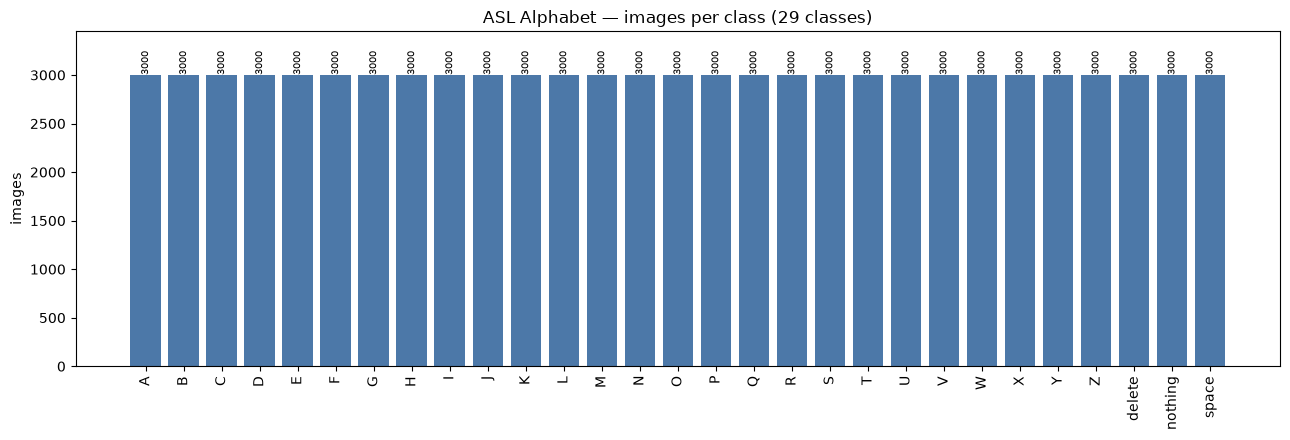

classes      : 29
total images : 87,000
min=3000  max=3000  mean=3000.0  std=0.0
saved figure -> docs/figures/class_balance.png


In [2]:
counts = class_counts(ROOT)
names = sorted(counts)                     # sort by class name for readable, stable order
values = [counts[c] for c in names]

fig, ax = plt.subplots(figsize=(13, 4.5))
bars = ax.bar(names, values, color="#4C78A8")
ax.set_ylabel("images")
ax.set_title(f"ASL Alphabet — images per class ({len(names)} classes)")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90)
ax.margins(y=0.15)
for b, v in zip(bars, values):
    ax.annotate(f"{v}", (b.get_x() + b.get_width() / 2, v),
                ha="center", va="bottom", fontsize=7, rotation=90)
fig.tight_layout()

out = FIG_DIR / "class_balance.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

arr = np.array(values)
print(f"classes      : {len(names)}")
print(f"total images : {arr.sum():,}")
print(f"min={arr.min()}  max={arr.max()}  mean={arr.mean():.1f}  std={arr.std():.1f}")
print(f"saved figure -> {out.relative_to(REPO_ROOT)}")

**Read-out.** Every one of the 29 classes holds **exactly 3,000 images** — `min = max =
mean = 3000`, `std = 0`, total **87,000**. The dataset is **perfectly balanced**, so class
imbalance is *not* a concern here and no re-weighting or resampling is needed.

That is exactly why balance is a red herring: with 3,000 near-identical frames per class,
the danger is **not** too-few examples — it is that those examples leak across a naive
split. That is what the next section demonstrates.

## 2 · The single-signer trap — consecutive frames are near-duplicates
`list_class_files` returns each class's frames in **capture order**. We display the first
12 frames of class `A` as a strip, then **measure** the effect: mean absolute pixel
difference between *consecutive* frames vs. between *far-apart* frames of the same class.

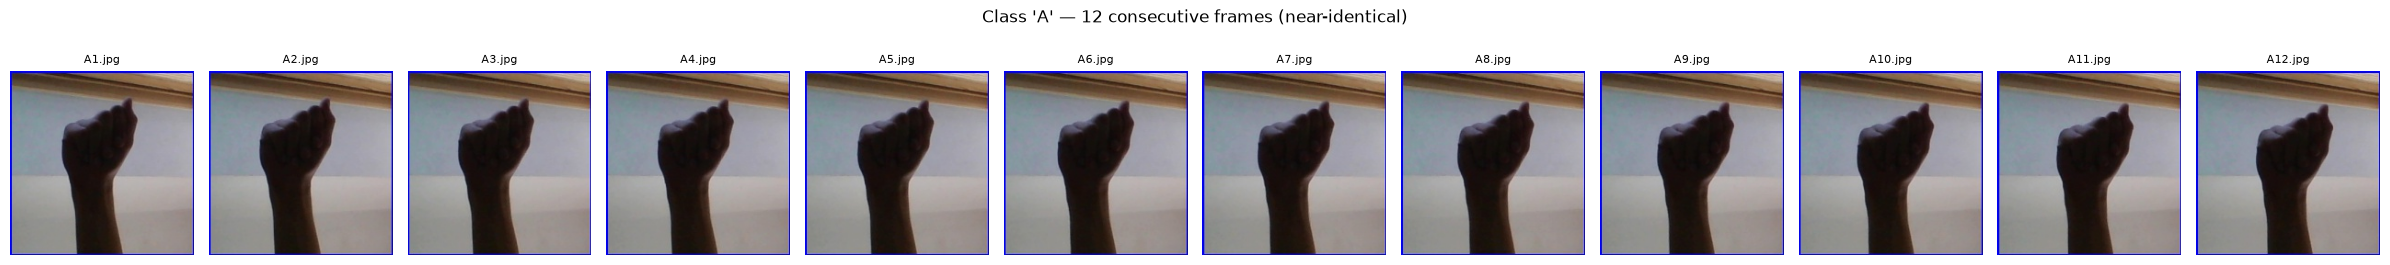

mean |dpixel|, consecutive frames :   2.97   (0-255 scale)
mean |dpixel|, far-apart frames   :  71.35
far-apart frames differ 24.0x more than consecutive ones


In [3]:
CLASS = "A"
N_CONSEC = 12
files = list_class_files(ROOT, CLASS)
strip = files[:N_CONSEC]

fig, axes = plt.subplots(1, len(strip), figsize=(2.0 * len(strip), 2.6))
for ax, f in zip(axes, strip):
    ax.imshow(cv2.cvtColor(cv2.imread(f), cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(f), fontsize=8)
    ax.axis("off")
fig.suptitle(f"Class '{CLASS}' — {len(strip)} consecutive frames (near-identical)", y=1.03)
fig.tight_layout()
plt.show()

# --- quantify: consecutive vs far-apart mean absolute pixel difference (0-255 scale) ---
def _load(path):
    return cv2.imread(path, cv2.IMREAD_COLOR).astype(np.float32)

consec_imgs = [_load(f) for f in strip]
consec_diff = float(np.mean([
    np.abs(consec_imgs[i + 1] - consec_imgs[i]).mean()
    for i in range(len(consec_imgs) - 1)
]))

rng = np.random.default_rng(0)
n = len(files)
far_diffs = []
for _ in range(20):
    i, j = int(rng.integers(0, n)), int(rng.integers(0, n))
    while abs(i - j) < n // 4:               # force the pair to be far apart in capture order
        i, j = int(rng.integers(0, n)), int(rng.integers(0, n))
    far_diffs.append(np.abs(_load(files[i]) - _load(files[j])).mean())
far_diff = float(np.mean(far_diffs))

print(f"mean |dpixel|, consecutive frames : {consec_diff:6.2f}   (0-255 scale)")
print(f"mean |dpixel|, far-apart frames   : {far_diff:6.2f}")
print(f"far-apart frames differ {far_diff / consec_diff:4.1f}x more than consecutive ones")

**Read-out.** Consecutive frames differ by only **~3 / 255** on average, while far-apart
frames of the *same* class differ by **~71 / 255** — roughly **24× more**. Neighbouring
frames are, for a model, effectively the *same image*. (Exact numbers are printed above.)

## 3 · The consequence — why a random split lies

A uniformly **random** train/val split shuffles these frames and drops adjacent,
near-identical neighbours on **both** sides of the split. At validation time the model is
scored on images that are pixel-for-pixel almost identical to ones it trained on, so it
only has to **memorise the signer, lighting, and background** — not the *sign*. The result
is a **fake ~99.9% validation accuracy** that collapses the moment a new hand, room, or
camera appears.

That is why this repo refuses a random split:

- **#3 — leakage-safe frame-range split.** Within each class, sort frames by capture order
  and send the first 80% to train and the tail to val, so neighbouring frames never
  straddle the boundary (`src.data.frame_range_split`, enforced by
  `tests/test_split_leakage.py`).
- **#15 — our own webcam test set** is the *real* benchmark. Even the honest frame-range
  val split still shares one signer/room/camera with training; the only trustworthy number
  comes from images we record ourselves and never train on. **No split of this Kaggle
  dataset — random or frame-range — is the real benchmark.**

## 4 · Confusable groups to watch
Some ASL handshapes are visually close and will dominate the errors. We flag three groups
now so they are on everyone's radar: **M / N / S / T**, **A / E**, **K / V**. One example
frame per letter, one row per group.

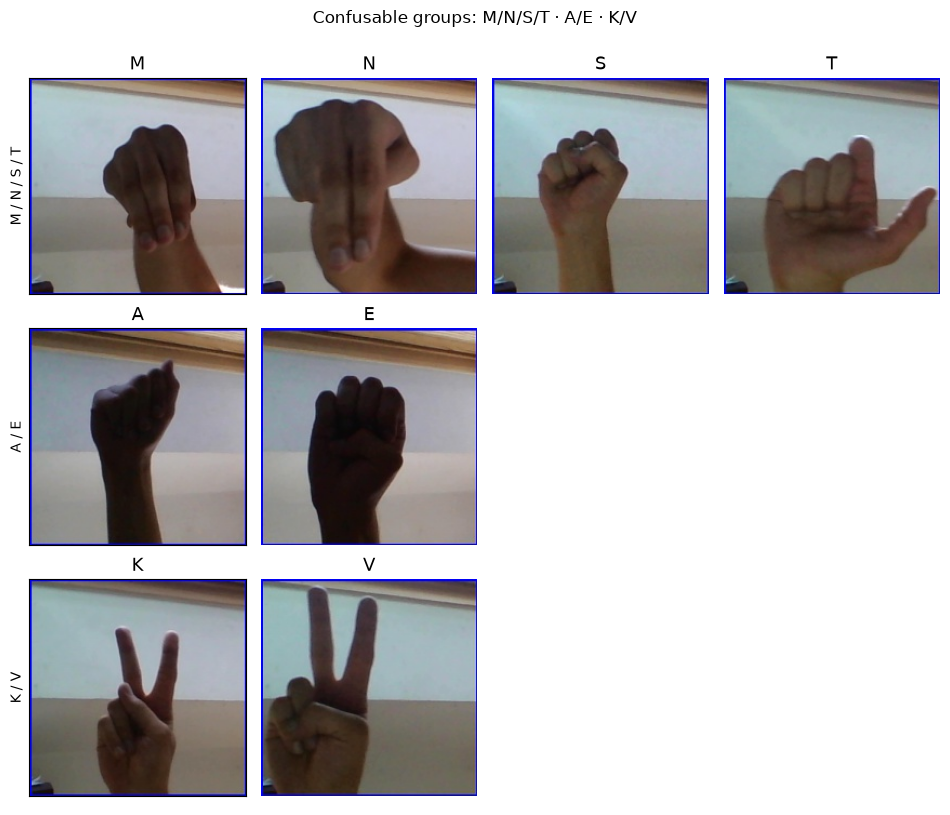

In [4]:
GROUPS = [["M", "N", "S", "T"], ["A", "E"], ["K", "V"]]
max_cols = max(len(g) for g in GROUPS)

fig, axes = plt.subplots(len(GROUPS), max_cols,
                         figsize=(2.4 * max_cols, 2.7 * len(GROUPS)))
for r, group in enumerate(GROUPS):
    for c in range(max_cols):
        ax = axes[r][c]
        if c < len(group):
            letter = group[c]
            img = cv2.cvtColor(cv2.imread(list_class_files(ROOT, letter)[0]), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(letter, fontsize=13)
        if c == 0:
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_ylabel(" / ".join(group), fontsize=10)   # label the row = the group
        else:
            ax.axis("off")
fig.suptitle("Confusable groups: M/N/S/T · A/E · K/V", y=1.0)
fig.tight_layout()
plt.show()

**Note for later.** These three groups — **M/N/S/T**, **A/E**, **K/V** — are where we
expect the confusion matrix to light up. They reappear in the evaluation harness (#7) and
in the real-webcam gap diagnosis (#16); the targeted fix is tracked in #12.

---
## Definition of Done (issue #2)

- [x] `notebooks/01_eda.ipynb` runs top-to-bottom with no errors (executed clean via `nbconvert`).
- [x] `docs/figures/class_balance.png` exists and is committed.
- [x] The consecutive-frame strip makes the near-duplicate trap **visually obvious** (and it is measured: ~3 vs ~71 mean |dpixel|).
- [x] The three confusion groups (M/N/S/T, A/E, K/V) are noted for later (#7, #12, #16).